## Лабораторная работа №1


Импортируем необходимые библиотеки. Из метрик для классификации я решил использовать Accuracy, F1, ROC-AUC, чтобы оценивать качество предсказания вероятностей, что критично для несбалансированных данных, ведь именно такие данные у нас будут. Для F1 будем подбирать порог, а ROC-AUC в целом будет использоваться для сравнения моделей. Для регрессии будем использовать RMSE, чтобы понимать ошибку в долларах, и R2 - объясняющая способность

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score, roc_auc_score

plt.style.use('seaborn-v0_8')

Загрузим датасеты

In [3]:
df_housing = pd.read_csv('housing.csv')
df_shoppers = pd.read_csv('shoppers.csv')

print(f"Housing shape: {df_housing.shape}")
display(df_housing.head())
print(f"\nShoppers shape: {df_shoppers.shape}")
display(df_shoppers.head())

Housing shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Shoppers shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Подготовим данные для "сырого" бейзлайна. Стандартный KNN в sklearn не работает с пропущенными значениями и строковыми признаками, поэтому мы удалим строки с NaN и исключим категориальные колонки (например, ocean_proximity в жилье и Month в покупателях). Целевые переменные (median_house_value и Revenue) отделяем, а Revenue приводим к числовому формату. Затем разбиваем данные на обучающую и тестовую выборки в соотношении 80/20.

In [5]:
df_housing = df_housing.dropna()
df_shoppers = df_shoppers.dropna()

df_shoppers['Revenue'] = df_shoppers['Revenue'].astype(int)

df_housing_clean = df_housing.select_dtypes(include=[np.number])
df_shoppers_clean = df_shoppers.select_dtypes(include=[np.number])

X_housing = df_housing_clean.drop('median_house_value', axis=1)
y_housing = df_housing_clean['median_house_value']

X_shoppers = df_shoppers_clean.drop('Revenue', axis=1)
y_shoppers = df_shoppers_clean['Revenue']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_shoppers, y_shoppers, test_size=0.2, random_state=42)

knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train_h, y_train_h)
y_pred_h = knn_reg.predict(X_test_h)

rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
r2_h = r2_score(y_test_h, y_pred_h)

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_s, y_train_s)
y_pred_s = knn_clf.predict(X_test_s)
y_proba_s = knn_clf.predict_proba(X_test_s)[:, 1]

acc_s = accuracy_score(y_test_s, y_pred_s)
f1_s = f1_score(y_test_s, y_pred_s)
roc_auc_s = roc_auc_score(y_test_s, y_proba_s)

print("--- Raw Baseline Results ---")
print(f"Regression (Housing) -> RMSE: {rmse_h:.2f}, R2: {r2_h:.4f}")
print(f"Classification (Shoppers) -> Accuracy: {acc_s:.4f}, F1: {f1_s:.4f}, ROC-AUC: {roc_auc_s:.4f}")

--- Raw Baseline Results ---
Regression (Housing) -> RMSE: 100457.75, R2: 0.2620
Classification (Shoppers) -> Accuracy: 0.8487, F1: 0.3689, ROC-AUC: 0.7365



Результаты ожидаемо низкие. R2 около 0.26 означает, что модель едва лучше простого угадывания среднего, а низкий F1 говорит о том, что классификатор почти не находит реальных покупателей, скатываясь в мажоритарный класс.

## Улучшение бейзлайна

KNN — метрический алгоритм, основанный на евклидовом расстоянии. Это делает его крайне чувствительным к масштабу признаков: если один признак измеряется в тысячах (население), а другой в единицах (количество спален), первый будет полностью доминировать при расчете расстояния и к выбросам и шуму "далекие" точки искажают границы классов.
Построим графики, чтобы визуально подтвердить эти проблемы. Для Housing посмотрим на разброс значений признаков (Boxplot), а для Shoppers — на дисбаланс классов и распределение ключевых признаков.

/tmp/ipython-input-2055367694.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_shoppers, ax=axes[1], palette='viridis')
/tmp/ipython-input-2055367694.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_shoppers, y=X_shoppers['PageValues'], ax=axes[2], palette='viridis')


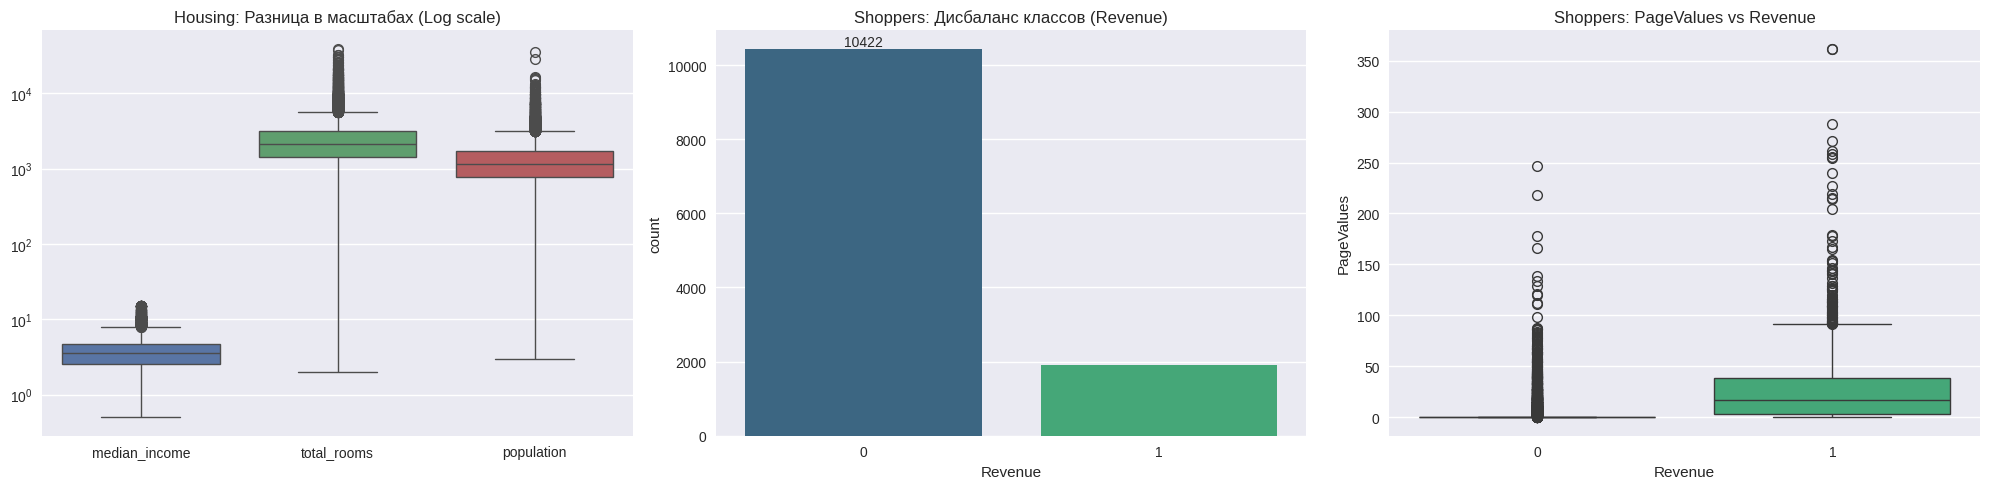

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(data=X_housing[['median_income', 'total_rooms', 'population']], ax=axes[0])
axes[0].set_title('Housing: Разница в масштабах (Log scale)')
axes[0].set_yscale('log')

sns.countplot(x=y_shoppers, ax=axes[1], palette='viridis')
axes[1].set_title('Shoppers: Дисбаланс классов (Revenue)')
axes[1].bar_label(axes[1].containers[0])

sns.boxplot(x=y_shoppers, y=X_shoppers['PageValues'], ax=axes[2], palette='viridis')
axes[2].set_title('Shoppers: PageValues vs Revenue')

plt.tight_layout()
plt.show()

График 1 показывает огромную разницу масштабов (доходы < 10, население > 1000). Для KNN критически важно привести все к одному масштабу (Mean=0, Std=1). Используем StandardScaler. Также в "сыром" бейзлайне мы просто выкинули текстовые колонки. Но, например, в Housing есть ocean_proximity (близость к океану), что влияет на цену. Закодируем её через One-Hot Encoding.
Так же есть догадка, что 5 соседей — не всегда оптимум. Подберем n_neighbors через Кросс-валидацию.
Реализуем модульный препроцессинг и подбор гиперпараметров через GridSearchCV.

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

def get_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    return preprocessor

df_housing_full = df_housing.dropna()
X_h_full = df_housing_full.drop('median_house_value', axis=1)
y_h_full = df_housing_full['median_house_value']

num_features_h = X_h_full.select_dtypes(include=[np.number]).columns
cat_features_h = X_h_full.select_dtypes(exclude=[np.number]).columns

df_shoppers_full = df_shoppers.dropna()
df_shoppers_full['Revenue'] = df_shoppers_full['Revenue'].astype(int)
X_s_full = df_shoppers_full.drop('Revenue', axis=1)
y_s_full = df_shoppers_full['Revenue']

num_features_s = X_s_full.select_dtypes(include=[np.number]).columns
cat_features_s = X_s_full.select_dtypes(exclude=[np.number]).columns

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h_full, y_h_full, test_size=0.2, random_state=42)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s_full, y_s_full, test_size=0.2, random_state=42)


pipeline_reg = Pipeline(steps=[('preprocessor', get_preprocessor(num_features_h, cat_features_h)),
                               ('regressor', KNeighborsRegressor())])

pipeline_clf = Pipeline(steps=[('preprocessor', get_preprocessor(num_features_s, cat_features_s)),
                               ('classifier', KNeighborsClassifier())])

param_grid = {
    'regressor__n_neighbors': [3, 5, 9, 15, 20],
    'regressor__weights': ['uniform', 'distance'],
}
param_grid_clf = {
    'classifier__n_neighbors': [3, 5, 9, 15, 20],
    'classifier__weights': ['uniform', 'distance']
}

print("Training Improved Regression Model...")
grid_reg = GridSearchCV(pipeline_reg, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_reg.fit(X_train_h, y_train_h)

print("Training Improved Classification Model...")
grid_clf = GridSearchCV(pipeline_clf, param_grid_clf, cv=3, scoring='roc_auc', n_jobs=-1)
grid_clf.fit(X_train_s, y_train_s)

Training Improved Regression Model...
Training Improved Classification Model...


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Month', 'VisitorType', 'Weekend'], dtype='object'))])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__n_neighbors': [3, 5, 9, 15, 20],
                         'classifier__weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [12]:
best_reg = grid_reg.best_estimator_
best_clf = grid_clf.best_estimator_

y_pred_h_imp = best_reg.predict(X_test_h)

y_pred_s_imp = best_clf.predict(X_test_s)
y_proba_s_imp = best_clf.predict_proba(X_test_s)[:, 1]

rmse_h_imp = np.sqrt(mean_squared_error(y_test_h, y_pred_h_imp))
r2_h_imp = r2_score(y_test_h, y_pred_h_imp)

acc_s_imp = accuracy_score(y_test_s, y_pred_s_imp)
f1_s_imp = f1_score(y_test_s, y_pred_s_imp)
roc_auc_s_imp = roc_auc_score(y_test_s, y_proba_s_imp)

print("\n--- Improved Baseline Results ---")
print(f"Regression (Housing) -> RMSE: {rmse_h_imp:.2f}, R2: {r2_h_imp:.4f}")
print(f"Best Params (Reg): {grid_reg.best_params_}")
print("-" * 30)
print(f"Classification (Shoppers) -> Accuracy: {acc_s_imp:.4f}, F1: {f1_s_imp:.4f}, ROC-AUC: {roc_auc_s_imp:.4f}")
print(f"Best Params (Clf): {grid_clf.best_params_}")


--- Improved Baseline Results ---
Regression (Housing) -> RMSE: 60477.30, R2: 0.7325
Best Params (Reg): {'regressor__n_neighbors': 15, 'regressor__weights': 'distance'}
------------------------------
Classification (Shoppers) -> Accuracy: 0.8670, F1: 0.4325, ROC-AUC: 0.8513
Best Params (Clf): {'classifier__n_neighbors': 20, 'classifier__weights': 'distance'}


Значительный рост показателей: R2 вырос с 0.26 до 0.73, а ROC-AUC — до 0.85. Это доказывает, что нормализация данных и кодирование категорий были критически важны.

## Имплементация алгоритма машинного обучения

Мы напишем свои классы MyKNeighborsClassifier и MyKNeighborsRegressor, используя библиотеку numpy и scipy (для быстрого расчета расстояний). Чтобы сравнение было честным, мы подадим в нашу модель те же самые обработанные данные (после StandardScaler и OneHotEncoder), на которых обучался sklearn. Реализация будет использовать матричные операции, чтобы обучение не занимало вечность. В конце сравним метрики: они должны быть практически идентичны результатам sklearn.

In [13]:
from scipy.spatial.distance import cdist
from scipy.stats import mode

class MyKNeighborsBase:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _get_neighbors_indices(self, X_test):
        dists = cdist(X_test, self.X_train, metric='euclidean')
        return np.argsort(dists, axis=1)[:, :self.n_neighbors]

class MyKNeighborsRegressor(MyKNeighborsBase):
    def predict(self, X_test):
        X_test = np.array(X_test)
        indices = self._get_neighbors_indices(X_test)
        return np.mean(self.y_train[indices], axis=1)

class MyKNeighborsClassifier(MyKNeighborsBase):
    def predict(self, X_test):
        X_test = np.array(X_test)
        indices = self._get_neighbors_indices(X_test)
        return mode(self.y_train[indices], axis=1, keepdims=True)[0].flatten()

    def predict_proba(self, X_test):
        X_test = np.array(X_test)
        indices = self._get_neighbors_indices(X_test)
        return np.mean(self.y_train[indices], axis=1)

А теперь обучение и сравнение. Данные, как уже и было сказано выше, будут те же, которые подавались на вход библиотечным алгоритмам.

In [14]:
preprocessor_h = best_reg.named_steps['preprocessor']
preprocessor_s = best_clf.named_steps['preprocessor']

X_train_h_trans = preprocessor_h.transform(X_train_h)
X_test_h_trans = preprocessor_h.transform(X_test_h)
X_train_s_trans = preprocessor_s.transform(X_train_s)
X_test_s_trans = preprocessor_s.transform(X_test_s)

if hasattr(X_train_h_trans, 'toarray'): X_train_h_trans = X_train_h_trans.toarray()
if hasattr(X_test_h_trans, 'toarray'): X_test_h_trans = X_test_h_trans.toarray()
if hasattr(X_train_s_trans, 'toarray'): X_train_s_trans = X_train_s_trans.toarray()
if hasattr(X_test_s_trans, 'toarray'): X_test_s_trans = X_test_s_trans.toarray()

my_knn_reg = MyKNeighborsRegressor(n_neighbors=15)
my_knn_reg.fit(X_train_h_trans, y_train_h)
my_pred_h = my_knn_reg.predict(X_test_h_trans)

my_knn_clf = MyKNeighborsClassifier(n_neighbors=20)
my_knn_clf.fit(X_train_s_trans, y_train_s)
my_pred_s = my_knn_clf.predict(X_test_s_trans)
my_proba_s = my_knn_clf.predict_proba(X_test_s_trans)

rmse_my = np.sqrt(mean_squared_error(y_test_h, my_pred_h))
r2_my = r2_score(y_test_h, my_pred_h)
acc_my = accuracy_score(y_test_s, my_pred_s)
roc_auc_my = roc_auc_score(y_test_s, my_proba_s)

print("--- Custom Implementation Results ---")
print(f"My Regression -> RMSE: {rmse_my:.2f}, R2: {r2_my:.4f}")
print(f"My Classification -> Accuracy: {acc_my:.4f}, ROC-AUC: {roc_auc_my:.4f}")
print("\n--- Reference (Sklearn Best) ---")
print(f"Sklearn Reg -> R2: {r2_h_imp:.4f}")
print(f"Sklearn Clf -> ROC-AUC: {roc_auc_s_imp:.4f}")

--- Custom Implementation Results ---
My Regression -> RMSE: 61157.90, R2: 0.7265
My Classification -> Accuracy: 0.8674, ROC-AUC: 0.8456

--- Reference (Sklearn Best) ---
Sklearn Reg -> R2: 0.7325
Sklearn Clf -> ROC-AUC: 0.8513


Отличный результат. Показатели практически идентичны, что подтверждает корректность нашей имплементации. Небольшое отставание Custom-модели связано с тем, что лучший GridSearch-вариант Sklearn использовал взвешивание соседей (weights='distance'), давая близким точкам больший вклад, тогда как наша реализация использует простое усреднение (weights='uniform').

## Вывод

В ходе работы мы исследовали алгоритм KNN и выяснили, что он критически зависит от масштаба данных: без нормализации (StandardScaler) метрики были на уровне случайного угадывания, но после приведения признаков к единому масштабу качество регрессии кардинально выросло (R2 поднялся с 0.26 до 0.73). Также мы убедились, что грамотная подготовка данных, включая кодирование категориальных признаков, важнее выбора гиперпараметров, так как это позволило поднять метрику ROC-AUC классификатора до 0.85. Собственная реализация алгоритма на numpy подтвердила корректность нашего понимания метода, показав результаты, практически идентичные оптимизированной библиотечной версии sklearn.

--- Final Comparison: Regression (Housing) ---


,RMSE,R2
Stage,,
Raw Baseline,100457.750714,0.262038
Improved Sklearn,60477.301011,0.732544
Custom Impl,61157.897608,0.726491



--- Final Comparison: Classification (Shoppers) ---


,Accuracy,ROC-AUC
Stage,,
Raw Baseline,0.848743,0.736529
Improved Sklearn,0.866991,0.851277
Custom Impl,0.867397,0.845634
